In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

spmv_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*spmv_128*.csv"))))
spmv_df["accelerator"] = "Ascend910B4"

In [21]:
spmv_df.head()

,benchname,operator,dtype,time_us,accelerator
0,conf5_4-8x8-05,spmv_128,fp16,289.06,Ascend910B4
1,conf5_4-8x8-05,spmv_128,fp16,295.49,Ascend910B4
0,cant,spmv_128,fp16,388.39,Ascend910B4
1,cant,spmv_128,fp16,389.17,Ascend910B4
0,pdb1HYS,spmv_128,fp16,366.79,Ascend910B4


In [22]:
cusparse_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*cu_sparse*.csv"))))
cusparse_df["time_us"] = cusparse_df["time_ms"] * 1000
cusparse_df["accelerator"] = "NVIDIA A5000"

In [23]:
eigen_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*eigen*.csv"))))
eigen_df["accelerator"] = "AMD EPYC 9554"

In [24]:
eigen_df.head()

,benchname,size,time_us,accelerator
0,pdb1HYS,2190591,955,AMD EPYC 9554
1,pdb1HYS,2190591,871,AMD EPYC 9554
2,pdb1HYS,2190591,860,AMD EPYC 9554
3,pdb1HYS,2190591,859,AMD EPYC 9554
4,pdb1HYS,2190591,860,AMD EPYC 9554


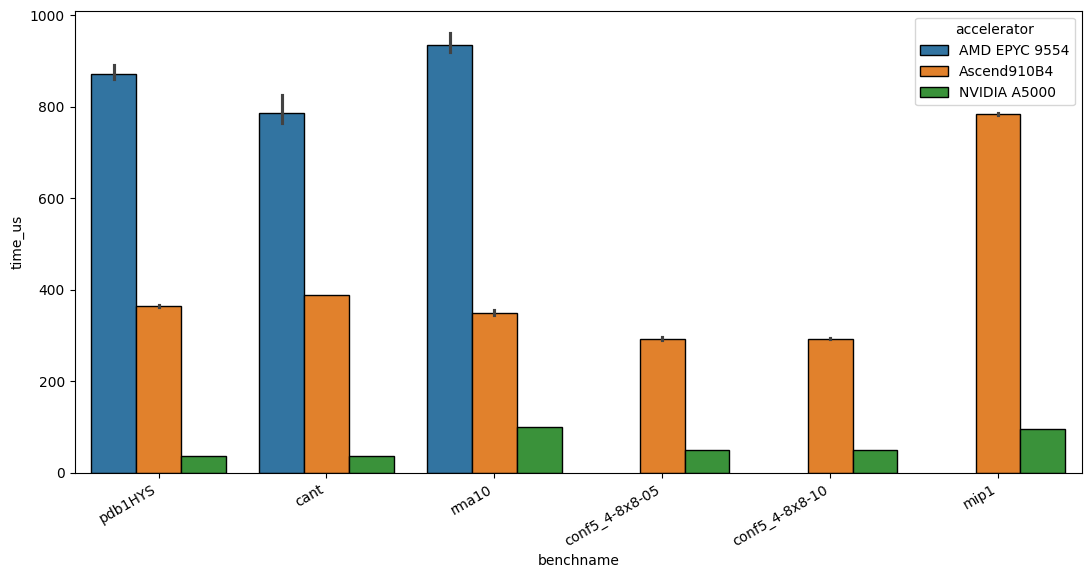

In [25]:
tot_df = pd.concat([eigen_df, spmv_df,cusparse_df])
plt.figure(figsize=(13,6))
ax = sns.barplot(data=tot_df, x="benchname", y="time_us", hue="accelerator", edgecolor="black")
plt.xticks(rotation=30, ha='right')

plt.savefig("spmv_soa_comparison.pdf")
